# K-Means Clustering — Breach Segments

Goal: segment the 7,795 breaches by **severity** (individuals affected) and **type**
(breach mechanism, entity type, business-associate involvement, timing) and report what the
clusters actually contain.

**Feature honesty notes**
- Features used: log10(individuals affected), submission year, business-associate flag, one-hot primary breach type, one-hot covered entity type.
- State was tested via frequency encoding (breach count per state) and **excluded**: it produced no geographic separation — every cluster's top states were simply the biggest states (CA/TX/NY) — while diluting an otherwise clean segment. The test is shown below. Geography is explorable via the EDA charts and dashboard filters instead.
- With one-hot categoricals, K-Means tends to partition along the dominant categorical axes and refine with the continuous features. That is what happens here — the value is in *which* combinations form coherent segments and how severity/timing differ between them.
- There is no rural/critical-access flag in this data, so no such claim is made.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

df = pd.read_csv("../data/breach_clean.csv", parse_dates=["Breach Submission Date"])
df = df.dropna(subset=["Individuals Affected", "Covered Entity Type", "Type of Breach"]).reset_index(drop=True)
print(f"{len(df):,} breaches with complete features")

7,788 breaches with complete features


## 1. Feature matrix

In [2]:
features = pd.DataFrame({
    "log_affected": np.log10(df["Individuals Affected"]),
    "year": df["Year"],
    "ba_present": (df["Business Associate Present"] == "Yes").astype(int),
})
features = pd.concat([features,
                      pd.get_dummies(df["Primary Breach Type"], prefix="bt").astype(int),
                      pd.get_dummies(df["Covered Entity Type"], prefix="et").astype(int)], axis=1)
FEATURE_COLS = list(features.columns)
print(features.shape)
features.head(3)

(7788, 14)


,log_affected,year,ba_present,bt_Hacking/IT Incident,bt_Improper Disposal,bt_Loss,bt_Other,bt_Theft,bt_Unauthorized Access/Disclosure,bt_Unknown,et_Business Associate,et_Health Plan,et_Healthcare Clearing House,et_Healthcare Provider
0,3.627058,2026,0,0,0,0,0,0,1,0,0,0,0,1
1,3.911530,2026,0,0,0,0,0,0,1,0,0,1,0,0
2,2.779596,2026,1,1,0,0,0,0,0,0,1,0,0,0


### Should state be a feature? (tested, then excluded)

In [3]:
state_freq = df["State"].map(df["State"].value_counts()).fillna(0)
feat_with_state = features.assign(state_freq=state_freq)

for label, F in [("without state", features), ("with state_freq", feat_with_state)]:
    Xs_ = StandardScaler().fit_transform(F)
    km_ = KMeans(n_clusters=5, random_state=42, n_init=10).fit(Xs_)
    labs = pd.Series(km_.labels_, index=df.index)
    top_states = {c: df.loc[labs == c, "State"].value_counts().head(2).index.tolist()
                  for c in sorted(labs.unique())}
    sil = silhouette_score(Xs_, km_.labels_, sample_size=3000, random_state=42)
    print(f"{label:16s} silhouette={sil:.3f}  cluster top states: {top_states}")

print()
print("With state_freq, every cluster's top states are just the largest states (CA/TX/NY/FL) --")
print("no geographic structure emerges, so state is excluded from the final model.")

without state    silhouette=0.412  cluster top states: {np.int32(0): ['TX', 'CA'], np.int32(1): ['TX', 'CA'], np.int32(2): ['CA', 'NY'], np.int32(3): ['CA', 'NY'], np.int32(4): ['CA', 'TX']}


with state_freq  silhouette=0.332  cluster top states: {np.int32(0): ['TX', 'CA'], np.int32(1): ['CA', 'TX'], np.int32(2): ['CA', 'NY'], np.int32(3): ['CA', 'NY'], np.int32(4): ['TX', 'IN']}

With state_freq, every cluster's top states are just the largest states (CA/TX/NY/FL) --
no geographic structure emerges, so state is excluded from the final model.


## 2. Choosing k (elbow + silhouette)

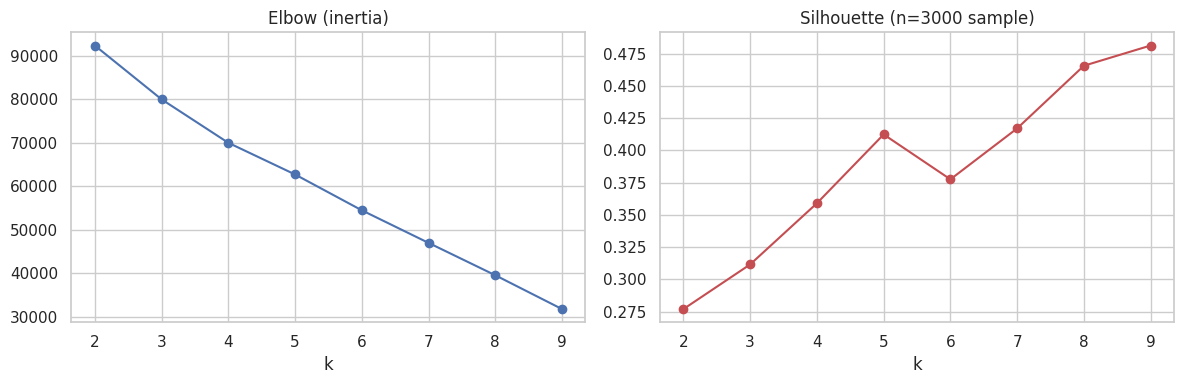

,k,inertia,silhouette
0,2,92343.0,0.277
1,3,79985.0,0.312
2,4,70005.0,0.359
3,5,62733.0,0.412
4,6,54505.0,0.378
5,7,47022.0,0.417
6,8,39589.0,0.466
7,9,31820.0,0.481


In [4]:
scaler_probe = StandardScaler().fit(features)
Xs = scaler_probe.transform(features)

ks = range(2, 10)
inertias, sils = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(Xs)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(Xs, km.labels_, sample_size=3000, random_state=RANDOM_STATE))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(ks), inertias, "o-"); axes[0].set_title("Elbow (inertia)"); axes[0].set_xlabel("k")
axes[1].plot(list(ks), sils, "o-", color="#C44E52"); axes[1].set_title("Silhouette (n=3000 sample)"); axes[1].set_xlabel("k")
plt.tight_layout(); plt.show()

pd.DataFrame({"k": list(ks), "inertia": np.round(inertias), "silhouette": np.round(sils, 3)})

Silhouette keeps creeping up at higher k because one-hot dummies reward splitting on ever-finer
categorical combinations. **k = 5** sits at a local silhouette peak and yields segments that are
distinct *and* interpretable, so it is used for the final model.

## 3. Final model (k = 5)

In [5]:
K = 5
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10)),
])
df["cluster"] = pipeline.fit_predict(features)

profile = df.groupby("cluster").agg(
    n=("cluster", "size"),
    median_affected=("Individuals Affected", "median"),
    total_affected_M=("Individuals Affected", lambda s: round(s.sum() / 1e6, 1)),
    mean_year=("Year", "mean"),
    ba_share=("Business Associate Present", lambda s: (s == "Yes").mean()),
    top_breach_type=("Primary Breach Type", lambda s: s.mode()[0]),
    top_entity=("Covered Entity Type", lambda s: s.mode()[0]),
).round({"mean_year": 1, "ba_share": 2})
profile["share"] = (profile.n / profile.n.sum()).round(2)
profile

,n,median_affected,total_affected_M,mean_year,ba_share,top_breach_type,top_entity,share
cluster,,,,,,,,
0,3429,8175.0,293.0,2021.8,0.21,Hacking/IT Incident,Healthcare Provider,0.44
1,1409,1654.0,23.7,2018.4,0.11,Unauthorized Access/Disclosure,Healthcare Provider,0.18
2,940,3000.0,189.4,2019.7,0.29,Hacking/IT Incident,Health Plan,0.12
3,1191,5696.0,519.7,2019.9,1.00,Hacking/IT Incident,Business Associate,0.15
4,819,2000.0,12.7,2014.4,0.02,Theft,Healthcare Provider,0.11


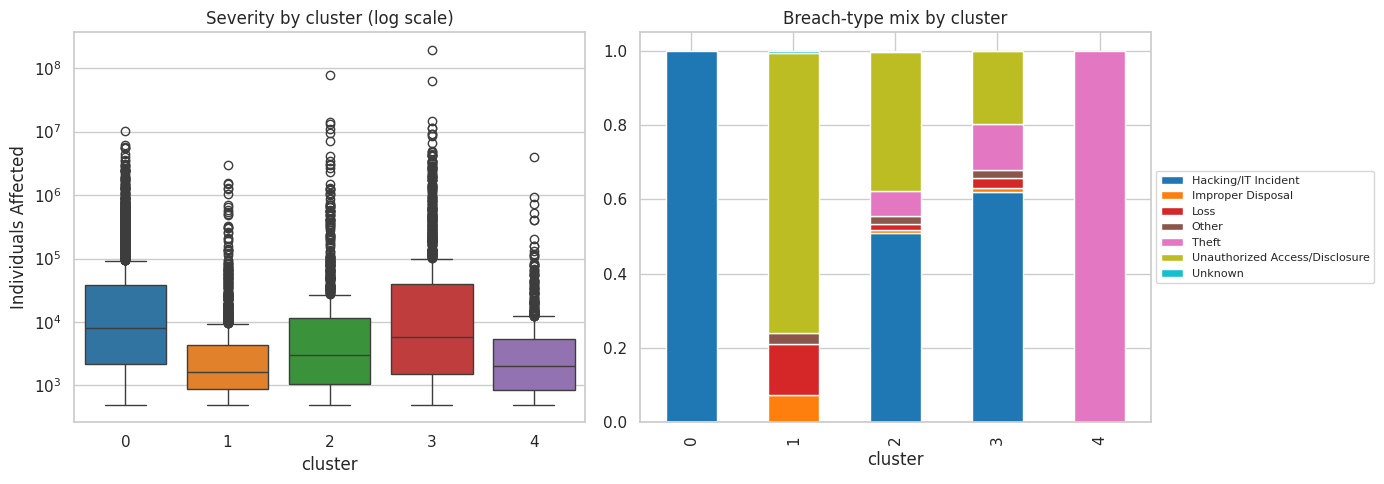

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="cluster", y="Individuals Affected", ax=axes[0],
            hue="cluster", palette="tab10", legend=False)
axes[0].set_yscale("log")
axes[0].set_title("Severity by cluster (log scale)")

ct = pd.crosstab(df["cluster"], df["Primary Breach Type"], normalize="index")
ct.plot(kind="bar", stacked=True, ax=axes[1], colormap="tab10")
axes[1].set_title("Breach-type mix by cluster")
axes[1].legend(loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=8)
plt.tight_layout(); plt.show()

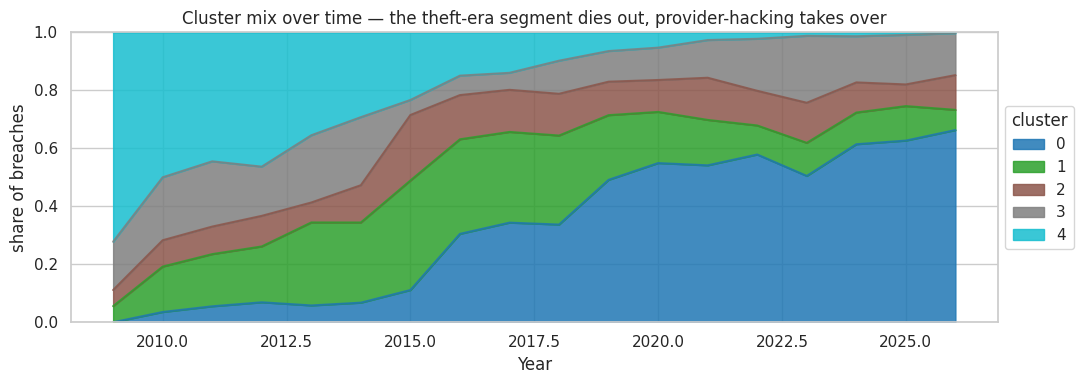

In [7]:
fig, ax = plt.subplots(figsize=(11, 4))
year_mix = pd.crosstab(df["Year"], df["cluster"], normalize="index")
year_mix.plot(kind="area", stacked=True, colormap="tab10", alpha=0.85, ax=ax)
ax.set_title("Cluster mix over time — the theft-era segment dies out, provider-hacking takes over")
ax.set_ylabel("share of breaches"); ax.set_ylim(0, 1)
ax.legend(title="cluster", loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.tight_layout(); plt.show()

## 4. What the clusters actually are

| Cluster | Segment (as observed) | Size | Median affected | Total affected | Character |
|---|---|---|---|---|---|
| 0 | **Modern provider hacking** | ~44% | ~8.2k | ~293M | Healthcare providers, 100% hacking/IT, centered ~2022 |
| 1 | **Provider human error / insider** | ~18% | ~1.7k | ~24M | Providers; unauthorized access/disclosure, loss, improper disposal — small breaches |
| 2 | **Health-plan breaches** | ~12% | ~3.0k | ~189M | Health plans; mixed hacking + disclosure; includes Anthem (78.8M) |
| 3 | **Business-associate / vendor breaches** | ~15% | ~5.7k | **~520M** | BA-reported; highest severity concentration — half of all affected records incl. Change Healthcare (192.7M) |
| 4 | **Legacy physical theft era** | ~11% | ~2.0k | ~13M | ~100% theft, mean year ≈ 2014; this segment has essentially vanished from new reports |

Takeaways the clustering supports:
- Severity concentrates in the **vendor cluster (3)**: 15% of breaches, ~50% of affected records.
- The **theft cluster (4)** is a historical artifact — encryption-at-rest and the decline of portable media effectively retired it.
- The **provider-hacking cluster (0)** is the current dominant regime and has a 4–5× higher median severity than the human-error cluster (1).

What the clustering does *not* show: anything about rural vs urban entities, financial cost, or
patient geography — those attributes aren't in the data.

## 5. Persist model

In [8]:
import json, os
os.makedirs("../models", exist_ok=True)

joblib.dump(pipeline, "../models/kmeans_breach_clusters.joblib")
with open("../models/feature_columns.json", "w") as f:
    json.dump(FEATURE_COLS, f, indent=2)
profile.to_csv("../models/cluster_profiles.csv")
df[["Name of Covered Entity", "State", "Covered Entity Type", "Individuals Affected",
    "Breach Submission Date", "Year", "Type of Breach", "Primary Breach Type",
    "Location of Breached Information", "Business Associate Present", "Status", "cluster"]] \
  .to_csv("../data/breach_clustered.csv", index=False)

print("saved:")
print("  models/kmeans_breach_clusters.joblib  (scaler + kmeans pipeline)")
print("  models/feature_columns.json           (exact training feature order)")
print("  models/cluster_profiles.csv")
print("  data/breach_clustered.csv             (per-breach cluster assignments, used by the app)")

saved:
  models/kmeans_breach_clusters.joblib  (scaler + kmeans pipeline)
  models/feature_columns.json           (exact training feature order)
  models/cluster_profiles.csv
  data/breach_clustered.csv             (per-breach cluster assignments, used by the app)
